# <center><span style="color:#336699">Introdução à Ciência de Dados</span></center>
<hr style="border:2px solid #0077b9;">

<br/>

<div style="text-align: center;font-size: 150%;"> 
    Análise das Citações do GEOINFO</br>
</div>

<br/>

<div style="text-align: center;font-size: 90%;">
    Gabrielly Prado e Giulia Tomazeli
    <br/><br/>
    Mestrado em Computação Aplicada, Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Última Atualização: 25 de Agosto de 2026
</div>

<br/>

<div style="text-align: center;"> 
    <b>Resumo.</b> Este Jupyter Notebook apresenta uma análise exploratória da base bibliométrica dos trabalhos que citam as publicações do GEOINFO.
</div>

# Bibliotecas

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import unicodedata
import re

# Configurações

In [51]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [52]:
PATH_GEOINFO = "../data/processed/geoinfo_final.csv"
PATH_CITACOES = "../data/processed/citacoes_final.csv"

# Carregamento dos dados

In [53]:
df_geoinfo = pd.read_csv(PATH_GEOINFO)
df_citacoes = pd.read_csv(PATH_CITACOES)
df_instituicoes = pd.read_csv("../data/processed/instituicoes_padronizadas.csv")
df_autores = pd.read_csv("../data/processed/autores_padronizados.csv")
df_scholar = pd.read_csv("../data/raw/citacoes_google_scholar.csv")
df_openalex = pd.read_csv("../data/raw/openalex_progresso.csv")

In [54]:
df_geoinfo.shape

(681, 28)

In [55]:
df_citacoes.shape

(2988, 28)

In [56]:
df_geoinfo.head(3)

,identificador,titulo_original,titulo,ano_original,ano,autores,instituicoes,idioma,pais,veiculo_publicacao,...,openalex_id,openalex_status,url,url_original,url_artigo,url_metadata,url_edicao,edicao,numero_edicao,fonte_dados
0,8JMKD2USPTW34P/4DKBAQH,NaN,Reproducible and empirical method refines Frac...,NaN,2025,"Adorno, Bruno Vargas; Nesbitt, Lorien; Amaral,...",National Institute for Space Research (INPE); ...,en,NaN,NaN,...,NaN,NaN,NaN,NaN,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,25a. Edição São José dos Campos 2025,25,geoinfo
1,8JMKD2USPTW34P/4DKBE9S,NaN,Potential Effects of Legal Reserve Exclusion o...,NaN,2025,"Andrade, Pedro Ribeiro; Rodrigues, Erick Teixe...",National Institute for Space Research (INPE); ...,en,NaN,NaN,...,NaN,NaN,NaN,NaN,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,25a. Edição São José dos Campos 2025,25,geoinfo
2,8JMKD2USPTW34P/4DKBSAB,NaN,Bill 191/2020: Illegal Mining and Land Use Lan...,NaN,2025,"Chuizaca-espinoza, Isabel Adriana; Amaral, Sil...",National Institute for Space Research (INPE),en,NaN,NaN,...,NaN,NaN,NaN,NaN,http://mtc-m16c.sid.inpe.br/col/sid.inpe.br/mt...,http://mtc-m16c.sid.inpe.br/sid.inpe.br/mtc-m1...,http://urlib.net/ibi/8JMKD2USPTW34P/4DKC4FB,25a. Edição São José dos Campos 2025,25,geoinfo


In [57]:
df_citacoes.head(3)

,identificador,titulo_original,titulo,ano_original,ano,autores,instituicoes,idioma,pais,veiculo_publicacao,...,openalex_id,openalex_status,url,url_original,url_artigo,url_metadata,url_edicao,edicao,numero_edicao,fonte_dados
0,citacao_0,Predicting Oceanic Wind Speed and Direction Us...,Modelando Ocorrências de Espécies Marinhas com...,2025,2026.0,"H Margotte, CS Hara, ATR Pozo",Universidade Federal do Paraná,NaN,BR,periodicos.univali.br,...,https://openalex.org/W7163993264,OK,https://periodicos.univali.br/index.php/acotb/...,NaN,NaN,NaN,NaN,NaN,NaN,citacoes_enriquecidas
1,citacao_1,Implementing a new automatic deforestation mon...,Beyond the reporting of disturbed areas: the u...,2025,2026.0,"W Leal Filho, FC Alves, MS Reis, VL Camilotti",Instituto Nacional de Pesquisas Espaciais; Uni...,en,BR,Springer,...,https://openalex.org/W7119509551,OK,https://link.springer.com/article/10.1186/s405...,NaN,NaN,NaN,NaN,NaN,NaN,citacoes_enriquecidas
2,citacao_2,Implementing a new automatic deforestation mon...,Configuration Assessment of Deter-RT: a New SA...,2025,2025.0,"MS Reis, J Doblas, LH Gusmão",Environmental Earth Observation Information Te...,en,AT; BR,researchgate.net,...,https://openalex.org/W7124672439,OK,https://www.researchgate.net/profile/Mariane-R...,NaN,NaN,NaN,NaN,NaN,NaN,citacoes_enriquecidas


# Análise exploratória dos dados

## Visão geral

### Trabalhos GEOINFO

In [58]:
df_geoinfo["ano"].min(), df_geoinfo["ano"].max()

(np.int64(1999), np.int64(2025))

In [59]:
df_geoinfo["ano"].value_counts().sort_index()

ano
1999    11
2000    18
2001    19
2002    20
2003    23
2004    35
2005    29
2006    22
2007    28
2008    21
2010    21
2011    17
2012    18
2013    17
2014    20
2015    23
2016    25
2017    37
2018    20
2019    43
2020    36
2021    29
2022    48
2023    61
2025    40
Name: count, dtype: int64

In [60]:
df_geoinfo.isna().sum()

identificador             0
titulo_original         681
titulo                    0
ano_original            681
ano                       0
autores                   0
instituicoes              0
idioma                    0
pais                    681
veiculo_publicacao      681
tipo_documento          681
doi                     681
topico                  681
subcampo                681
campo                   681
dominio_tematico        681
fonte_publicacao        681
status_acesso_aberto    681
openalex_id             681
openalex_status         681
url                     681
url_original            681
url_artigo                0
url_metadata              0
url_edicao                0
edicao                    0
numero_edicao             0
fonte_dados               0
dtype: int64

### Trabalhos citantes

In [61]:
df_citacoes["ano"].min(), df_citacoes["ano"].max()

(np.float64(1901.0), np.float64(2026.0))

In [62]:
df_citacoes.isna().sum()

identificador              0
titulo_original            0
titulo                     0
ano_original               0
ano                      418
autores                    0
instituicoes            1480
idioma                   828
pais                    1481
veiculo_publicacao       213
tipo_documento           793
doi                     1566
topico                   802
subcampo                 802
campo                    802
dominio_tematico         802
fonte_publicacao        1368
status_acesso_aberto     793
openalex_id              793
openalex_status            7
url                      334
url_original            2988
url_artigo              2988
url_metadata            2988
url_edicao              2988
edicao                  2988
numero_edicao           2988
fonte_dados                0
dtype: int64

### Indicadores gerais

In [63]:
resumo = pd.DataFrame({
    "Indicador": [
        "Trabalhos GEOINFO",
        "Trabalhos citantes",
        "Anos analisados",
        "Autores citantes",
        "Instituições (Origem)",
        "Idioma",
        "Pais",
        "Instituições (Citante)",
        "Veículos de publicação",
        "Tipos de documento",
        "Áreas do conhecimento"
    ],

    "Quantidade": [
        df_geoinfo["titulo"].nunique(),
        df_citacoes["identificador"].nunique(),
        df_citacoes["ano"].nunique(),
        df_citacoes["autores"].nunique(),
        df_instituicoes["instituicoes"].dropna().nunique(),
        df_citacoes["idioma"].dropna().nunique(),
        df_citacoes["pais"].dropna().nunique(),
        df_citacoes["instituicoes"].dropna().nunique(),
        df_citacoes["veiculo_publicacao"].dropna().nunique(),
        df_citacoes["tipo_documento"].dropna().nunique(),
        df_citacoes["campo"].dropna().nunique()
    ]
})

print("\nTabela dos Indicadores")
print(resumo.to_string(index=False))


Tabela dos Indicadores
             Indicador  Quantidade
     Trabalhos GEOINFO         681
    Trabalhos citantes        2988
       Anos analisados          32
      Autores citantes        2349
 Instituições (Origem)        1370
                Idioma          19
                  Pais         221
Instituições (Citante)         903
Veículos de publicação         371
    Tipos de documento          19
 Áreas do conhecimento          22


In [64]:
df_citacoes_sem = df_citacoes.drop(columns=["numero_edicao", "edicao", "url_metadata", "url_edicao", "url_original", "url_artigo", "openalex_status", "openalex_id"])

In [65]:
qualidade = pd.DataFrame({
    "nulos": df_citacoes_sem.isna().sum(),
    "nulos_%": df_citacoes_sem.isna().mean() * 100,
    "unicos": df_citacoes_sem.nunique()
})

qualidade = (qualidade.sort_values("nulos_%", ascending=False))
qualidade

,nulos,nulos_%,unicos
doi,1566,52.409639,1251
pais,1481,49.564926,221
instituicoes,1480,49.531459,903
fonte_publicacao,1368,45.783133,586
idioma,828,27.710843,19
subcampo,802,26.840696,116
topico,802,26.840696,426
campo,802,26.840696,22
dominio_tematico,802,26.840696,4
status_acesso_aberto,793,26.539491,6


### Estatísticas gerais das citações

In [66]:
citacoes_por_artigo = (
    df_citacoes
    .groupby("titulo_original")
    .size()
    .reset_index(name="citacoes")
    .sort_values("citacoes", ascending=False)
)

In [67]:
citacoes_por_artigo["citacoes"].describe()

count    421.000000
mean       7.097387
std       11.373215
min        1.000000
25%        2.000000
50%        4.000000
75%        8.000000
max      143.000000
Name: citacoes, dtype: float64

# Análise geral das citações

## Quais são os trabalhos mais citados do GEOINFO?

In [68]:
top_trabalhos = (df_citacoes.groupby("titulo_original").size().sort_values(ascending=False).head(10))
top_trabalhos


titulo_original
TerraLib: technology in support of GIS innovation                                               143
Spatial information appliances: a next generation of geographic information systems              78
A flexible addressing system for approximate geocoding                                           69
Ontologias e interoperabilidade semântica entre SIGs                                             61
Aplicaçőes de estimadores bayesianos empíricos para análise espacial de taxas de mortalidade     48
Local spatial data infrastructures based on a service-oriented architecture                      43
Fast point-feature label placement algorithm for real time screen maps                           40
Issues on interoperability and integration of heterogeneous geographical data                    39
Trajectory data warehouses: proposal of design and application to exploit data                   38
Modelling spatial relations by generalized proximity matrices                       

## Quais os autores mais citados?

In [69]:
autores = pd.read_csv("../data/processed/autores_padronizados.csv")
top_autores = autores[["autores", "ocorrencias"]].sort_values("ocorrencias", ascending=False).reset_index(drop=True)

top_autores

,autores,ocorrencias
0,"Câmara, Gilberto",37
1,"Körting, Thales Sehn",30
2,"Queiroz, Gilberto Ribeiro de",27
3,"Vinhas, Lúbia",25
4,"Monteiro, Antônio Miguel Vieira",25
...,...,...
4053,"Simőes, Philipe Souza",1
4054,"J Lisboa Filho, C Iochpe",1
4055,"V Petkevitch, P Apparicio",1
4056,"AC Vianna, AC de Paiva, M Gattass",1


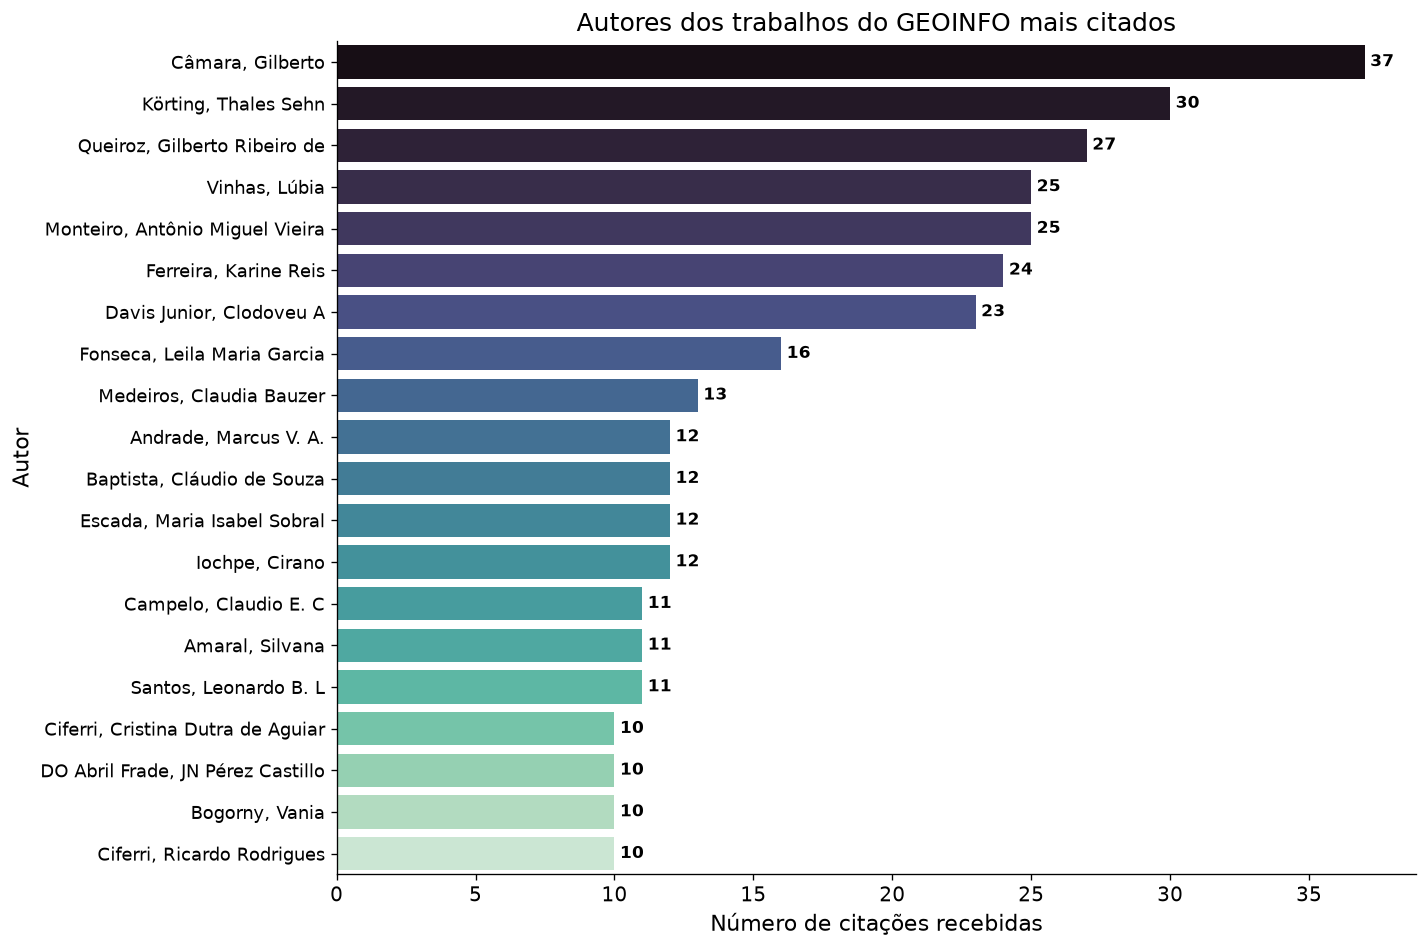

In [70]:
top_autores = (
    autores[["autores", "ocorrencias"]]
    .sort_values("ocorrencias", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(data=top_autores, x="ocorrencias", y="autores", hue="autores", palette="mako", legend=False)
ax.set_title("Autores dos trabalhos do GEOINFO mais citados", fontsize=15)
ax.set_xlabel("Número de citações recebidas", fontsize=13)
ax.set_ylabel("Autor", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_autores["ocorrencias"]):
    ax.text(v + 0.2, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

## Em quais países os trabalhos do GEOINFO são mais utilizados?

In [71]:
top_paises = (
    df_citacoes["pais"]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
    .loc[lambda x: (x != "") & (x != "Não informado")]
    .value_counts()
    .head(10)
    .sort_values()
)

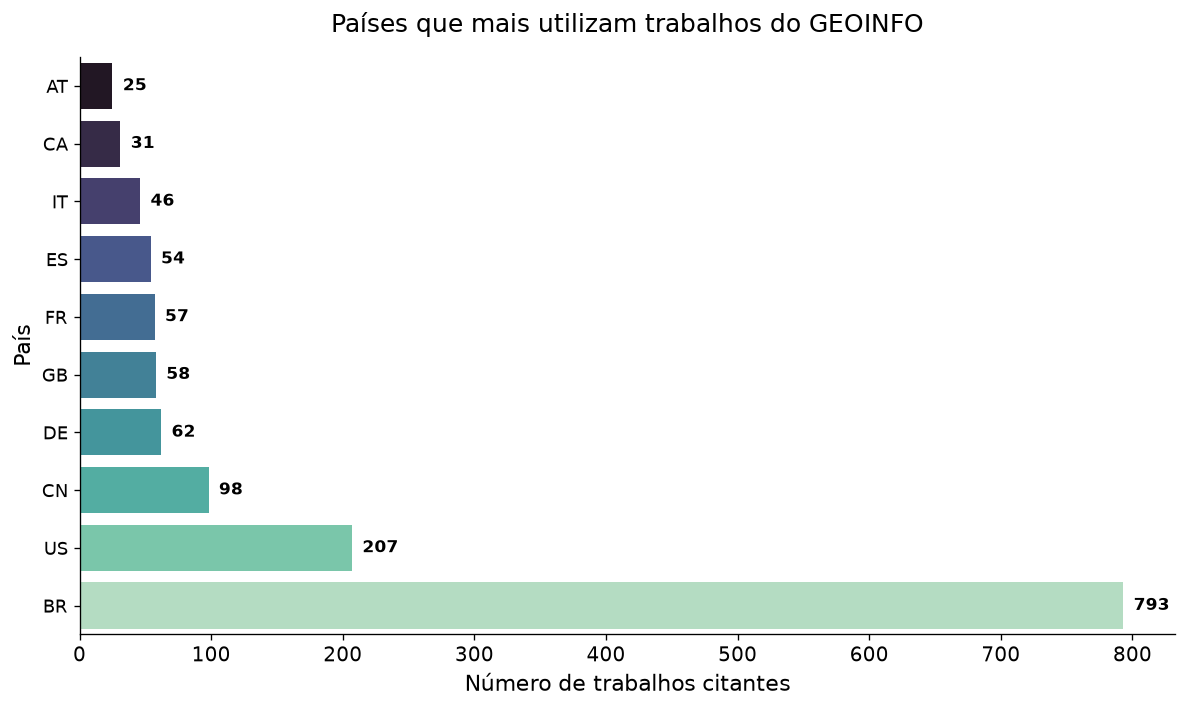

In [72]:
plt.figure(figsize=(10, 6))

colors = sns.color_palette("mako", len(top_paises))

ax = sns.barplot(x=top_paises.values,  y=top_paises.index,  palette=colors, hue=top_paises.index, legend=False)

ax.set_title("Países que mais utilizam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("País", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_paises.values):
    ax.text(v + (max(top_paises.values) * 0.01), i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Quais instituições mais citam trabalhos do GEOINFO?

In [73]:
top_instituicoes = (df_citacoes["instituicoes"].dropna().str.split(";").explode().str.strip())
top_instituicoes = (top_instituicoes[~top_instituicoes.isin(["", "Não informado"])].value_counts().head(10).sort_values())

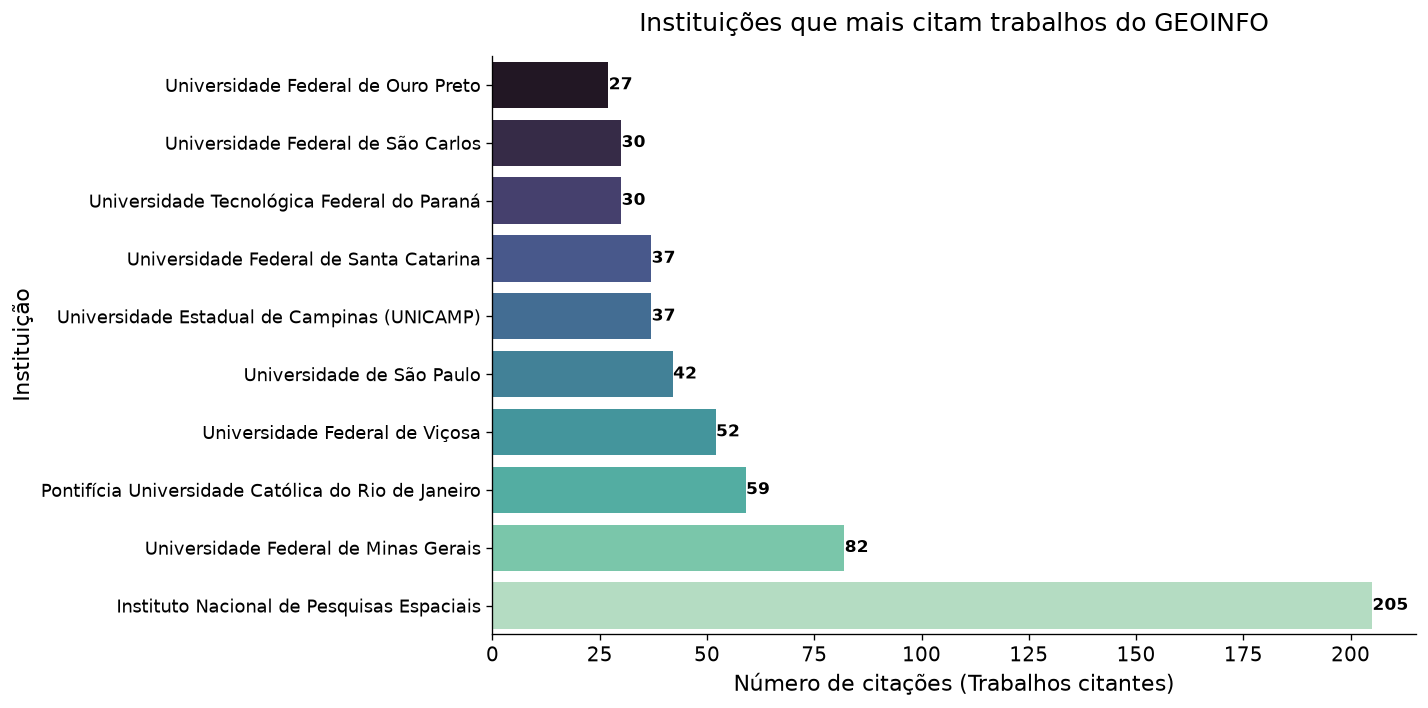

In [74]:
plt.figure(figsize=(12, 6))

COLORS = sns.color_palette("mako", len(top_instituicoes))

ax = sns.barplot(x=top_instituicoes.values,  y=top_instituicoes.index,  palette=COLORS, hue=top_instituicoes.index, legend=False)

ax.set_title("Instituições que mais citam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de citações (Trabalhos citantes)", fontsize=13)
ax.set_ylabel("Instituição", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_instituicoes.values):
    ax.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Em quais idiomas os trabalhos citantes foram publicados?

In [75]:
idiomas = (df_citacoes["idioma"].dropna())
idiomas = idiomas[~idiomas.isin(["Não informado"])].value_counts()

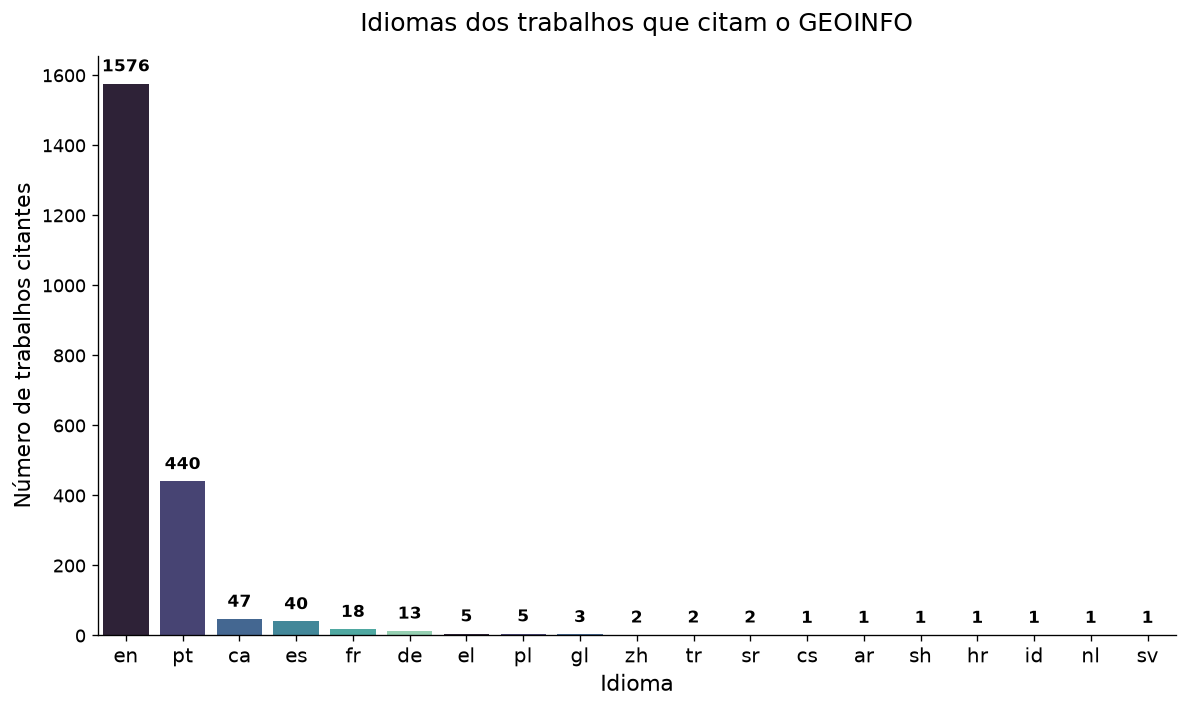

In [76]:
plt.figure(figsize=(10, 6))

base_colors = sns.color_palette("mako", 6)
colors = [base_colors[i % len(base_colors)] for i in range(len(idiomas))]

ax = sns.barplot(x=idiomas.index,  y=idiomas.values,  palette=colors, hue=idiomas.index)

ax.set_title("Idiomas dos trabalhos que citam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Idioma", fontsize=13)
ax.set_ylabel("Número de trabalhos citantes", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(idiomas.values):
    ax.text(i, v + (max(idiomas.values) * 0.015), f"{int(v)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## E os idiomas dos trabalhos do GEOINFO?

In [77]:
idiomas = (df_geoinfo["idioma"].dropna())
idiomas = idiomas[~idiomas.isin(["Não informado"])].value_counts()

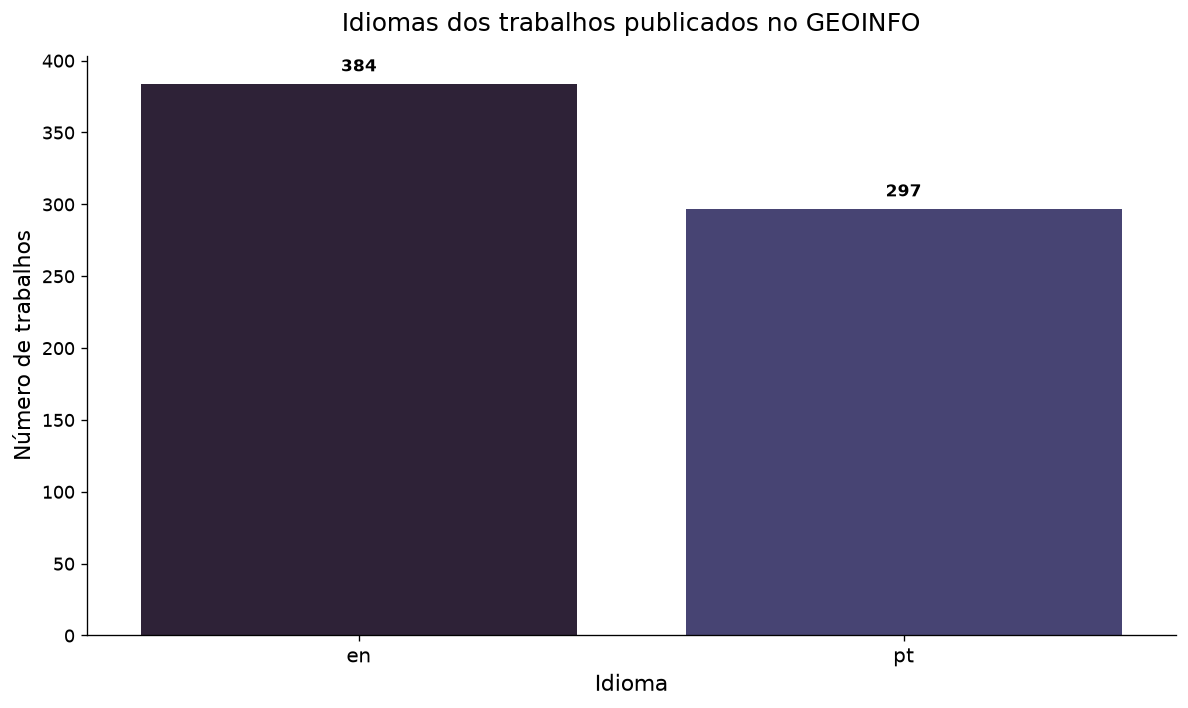

In [78]:
plt.figure(figsize=(10, 6))

base_colors = sns.color_palette("mako", 6)
colors = [base_colors[i % len(base_colors)] for i in range(len(idiomas))]

ax = sns.barplot(x=idiomas.index,  y=idiomas.values,  palette=colors, hue=idiomas.index)

ax.set_title("Idiomas dos trabalhos publicados no GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Idioma", fontsize=13)
ax.set_ylabel("Número de trabalhos", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(idiomas.values):
    ax.text(i, v + (max(idiomas.values) * 0.015), f"{int(v)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Quais são os principais veículos que citam trabalhos do GEOINFO?

In [79]:
VEICULOS_MANUAIS = {
    "journals-sol.sbc.org.br": "Sociedade Brasileira de Computação (SBC)",
    "Taylor & Francis": "Taylor & Francis",
    "mdpi.com": "MDPI",
    "dl.acm.org": "Association for Computing Machinery (ACM)",
    "mtc-m16c.sid.inpe.br": "Instituto Nacional de Pesquisas Espaciais (INPE)",
    "Elsevier": "Elsevier",
    "academia.edu": "Academia.edu",
    "researchgate.net": "ResearchGate",
    "ieeexplore.ieee.org": "Institute of Electrical and Electronics Engineers (IEEE)",
    "Springer": "Springer",
}

In [80]:
top_veiculos = (
    df_citacoes["veiculo_publicacao"]
    .dropna()
    .replace(VEICULOS_MANUAIS)
    .loc[lambda x: (x != "2009") & (~x.isin(["Não informado"]))]
    .value_counts()
    .head(10)
    .sort_values()
)

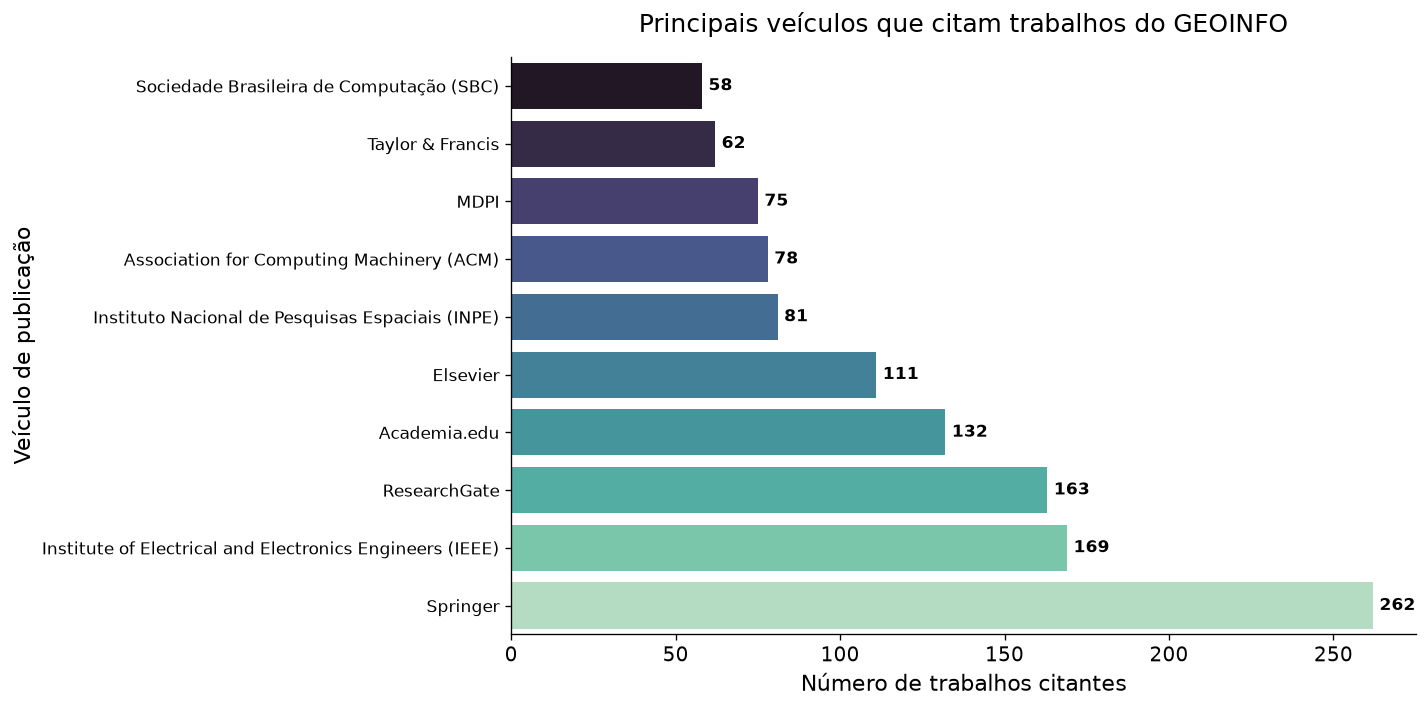

In [81]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("mako", len(top_veiculos))

ax = sns.barplot(x=top_veiculos.values, y=top_veiculos.index, palette=colors, hue=top_veiculos.index)

ax.set_title("Principais veículos que citam trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Veículo de publicação", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=10)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_veiculos.values):
    ax.text(v + 2, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

## Como evoluiu o número de citações ao longo dos anos?

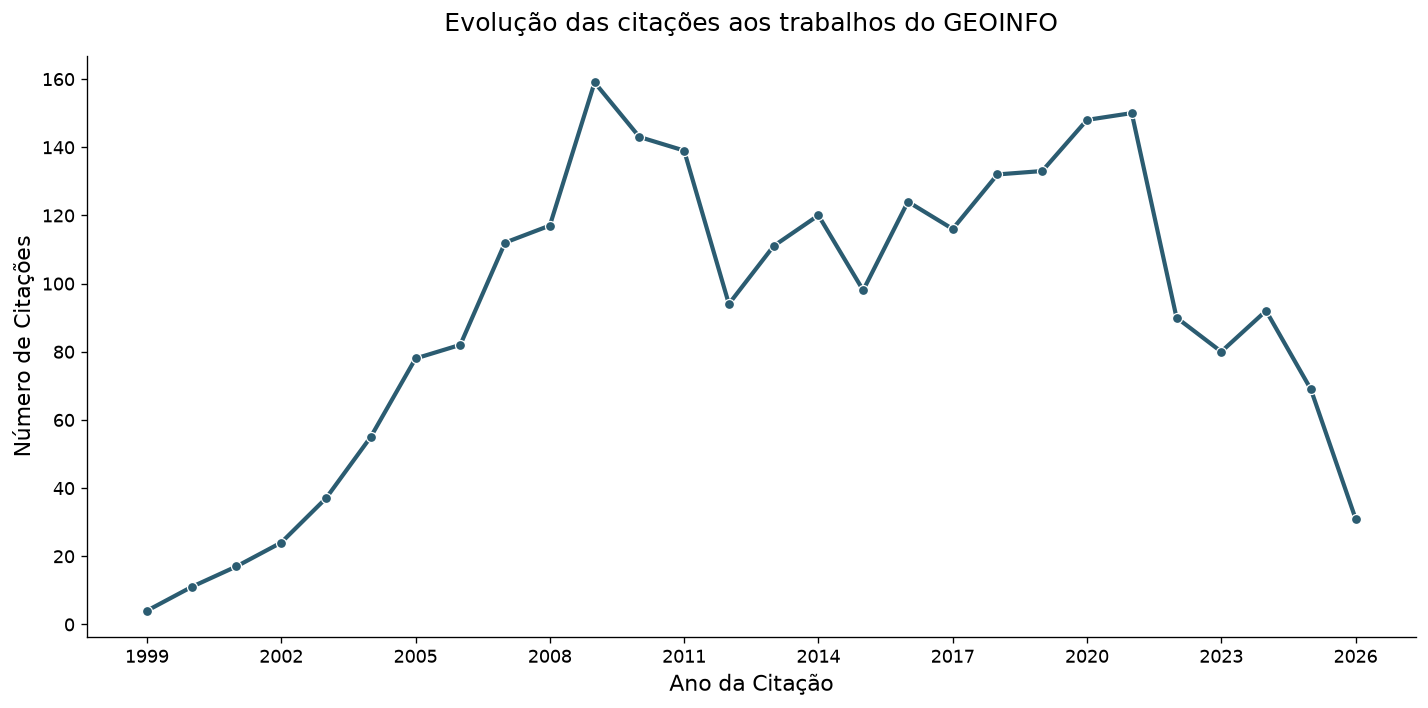

In [82]:
df_validas = df_citacoes[df_citacoes["ano"].between(1999, 2026)]

citacoes_ano = df_validas["ano"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

color_line = "#2b5c71"

ax = sns.lineplot(x=citacoes_ano.index,  y=citacoes_ano.values,  marker="o",  linewidth=2.5,  color=color_line)

ax.set_title("Evolução das citações aos trabalhos do GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Ano da Citação", fontsize=13)
ax.set_ylabel("Número de Citações", fontsize=13)

ax.set_xticks(range(1999, int(citacoes_ano.index.max()) + 1, 3))

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

sns.despine()

plt.tight_layout()
plt.show()

## Quais áreas do conhecimento mais utilizam pesquisas publicadas no GEOINFO?

In [83]:
top_areas = (df_citacoes["dominio_tematico"].dropna())
top_areas = (top_areas[~top_areas.isin(["Não informado"])].value_counts().head(10).sort_values())

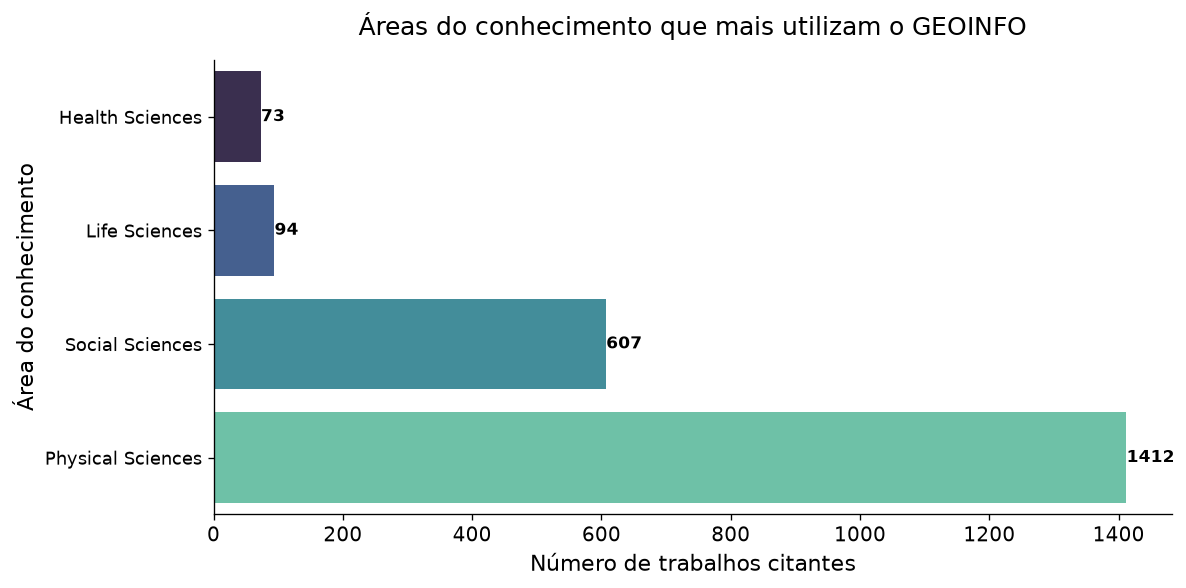

In [84]:
plt.figure(figsize=(10, 5))

colors = sns.color_palette("mako", len(top_areas))

ax = sns.barplot(x=top_areas.values,  y=top_areas.index,  palette=colors, hue=top_areas.index)

ax.set_title("Áreas do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Área do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

# adiciona os rótulos numéricos nas barras
for i, v in enumerate(top_areas.values):
    ax.text(v + 0.4, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

In [85]:
top_campos = (df_citacoes["campo"].dropna())
top_campos = (top_campos[~top_campos.isin(["Não informado"])].value_counts().head(10).sort_values() )

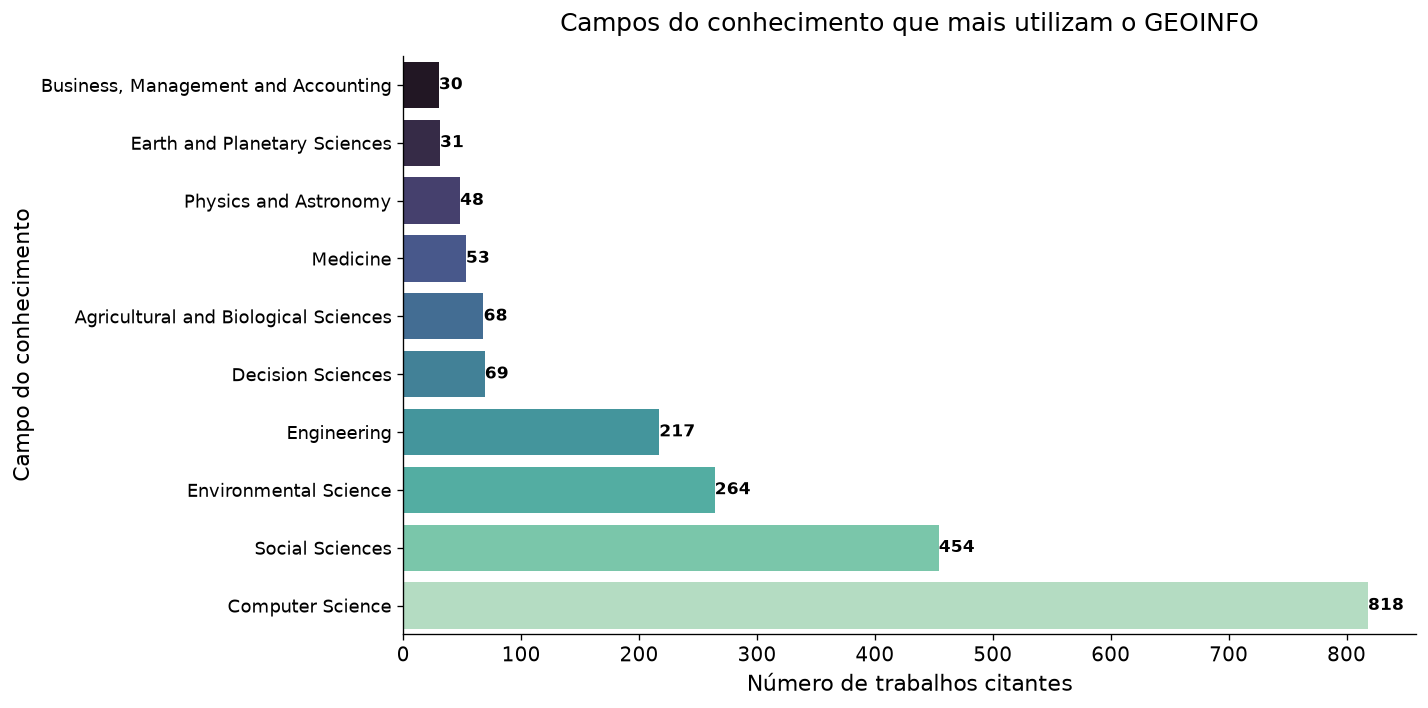

In [86]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("mako", len(top_campos))

ax = sns.barplot(x=top_campos.values, y=top_campos.index,  palette=colors, hue=top_campos.index)

ax.set_title("Campos do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Campo do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

for i, v in enumerate(top_campos.values):
    ax.text(v + 0.2, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

In [87]:
top_subcampos = (df_citacoes["subcampo"].dropna())
top_subcampos = (top_subcampos[~top_subcampos.isin(["Não informado"])].value_counts().head(10).sort_values())

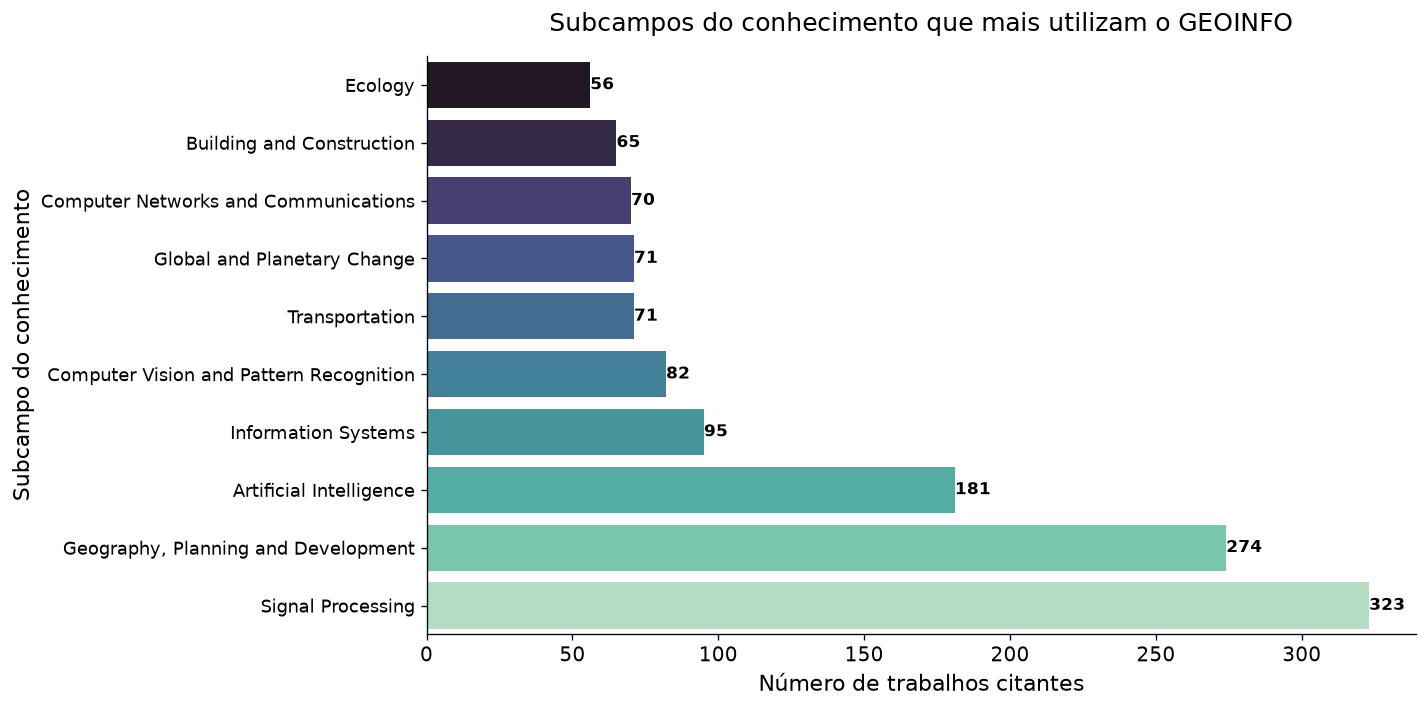

In [88]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("mako", len(top_subcampos))

ax = sns.barplot(x=top_subcampos.values,  y=top_subcampos.index,  palette=colors, hue=top_subcampos.index)

ax.set_title("Subcampos do conhecimento que mais utilizam o GEOINFO", fontsize=15, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=13)
ax.set_ylabel("Subcampo do conhecimento", fontsize=13)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

if ax.get_legend() is not None:
    ax.get_legend().remove()

for i, v in enumerate(top_subcampos.values):
    ax.text(v + 0.1, i, f"{int(v)}", va="center", fontsize=10, fontweight="bold")

sns.despine()

plt.tight_layout()
plt.show()

# Comparação das bases

In [89]:
dados_indicadores = {
    "Indicador": [
        "Trabalhos GEOINFO",
        "Trabalhos Citantes",
        "Autores Citantes",
        "Anos Analisados",
        "Instituições (Origem)",
        "Instituições (Citante)",
        "Veículos de Publicação",
        "Países",
        "Tipos de Documento",
        "Áreas do Conhecimento",
        "Idiomas"
    ],
    "Quantidade": [
        df_geoinfo["identificador"].nunique(),
        df_citacoes["identificador"].nunique(),
        df_citacoes["autores"].dropna().nunique(),
        df_citacoes["ano"].nunique(),
        df_geoinfo["instituicoes"].dropna().nunique(),
        df_citacoes["instituicoes"].dropna().nunique(),
        df_citacoes["veiculo_publicacao"].dropna().nunique(),
        df_citacoes["pais"].dropna().nunique(),
        df_citacoes["tipo_documento"].dropna().nunique(),
        df_citacoes["dominio_tematico"].dropna().nunique(),
        df_citacoes["idioma"].dropna().nunique(),
    ],
    "Fonte": [
        "Scholar", "Scholar", "Scholar", "Scholar",
        "Scholar", "Scholar", "Scholar",
        "OpenAlex", "OpenAlex", "OpenAlex",
        "OpenAlex"
    ]
}

df_indicadores = pd.DataFrame(dados_indicadores)

print("-=-=- Tabela dos Indicadores -=-=-")
print(df_indicadores.to_string(index=False))

-=-=- Tabela dos Indicadores -=-=-
             Indicador  Quantidade    Fonte
     Trabalhos GEOINFO         681  Scholar
    Trabalhos Citantes        2988  Scholar
      Autores Citantes        2349  Scholar
       Anos Analisados          32  Scholar
 Instituições (Origem)         326  Scholar
Instituições (Citante)         903  Scholar
Veículos de Publicação         371  Scholar
                Países         221 OpenAlex
    Tipos de Documento          19 OpenAlex
 Áreas do Conhecimento           4 OpenAlex
               Idiomas          19 OpenAlex


## Análise de cobertura dos artigos GEOINFO

In [90]:
def normalizar_titulo(titulo):
    if pd.isna(titulo):
        return ""

    titulo = str(titulo).lower()

    # remove acentos
    titulo = unicodedata.normalize("NFKD", titulo)
    titulo = "".join(c for c in titulo if not unicodedata.combining(c))

    # remove pontuação
    titulo = re.sub(r"[^\w\s]", " ", titulo)

    # normaliza espaços
    titulo = re.sub(r"\s+", " ", titulo).strip()
    return titulo


# filtra os trabalhos encontrados no OpenAlex
df_openalex_encontrados = df_openalex[df_openalex["status"].eq("OK")].copy()

# cria chave para identificar publicacao
df_openalex_encontrados["chave"] = (df_openalex_encontrados["titulo_original"].apply(normalizar_titulo))

df_scholar = df_scholar.copy()
df_scholar["chave"] = (df_scholar["titulo_original"].apply(normalizar_titulo))

# conjuntos de publicacao encontrados
openalex = set(df_openalex_encontrados.loc[df_openalex_encontrados["chave"] != "", "chave"])
scholar = set(df_scholar.loc[df_scholar["chave"] != "","chave"])

# sobreposicao
apenas_scholar = scholar - openalex
ambas = scholar & openalex
apenas_openalex = openalex - scholar

total_scholar = len(scholar)
total_openalex = len(openalex)
total_ambas = len(ambas)

df_sobreposicao = pd.DataFrame({
    "Categoria": [
        "Apenas Google Scholar",
        "Em ambas as bases",
        "Apenas OpenAlex"
    ],
    "Total de trabalhos": [
        len(apenas_scholar),
        len(ambas),
        len(apenas_openalex)
    ]
})

# percentual em relação ao total de trabalhos únicos
total_unico = len(scholar | openalex)

df_sobreposicao["Percentual (%)"] = (df_sobreposicao["Total de trabalhos"] / total_unico * 100)

print(df_sobreposicao)

               Categoria  Total de trabalhos  Percentual (%)
0  Apenas Google Scholar                 100       17.152659
1      Em ambas as bases                 321       55.060034
2        Apenas OpenAlex                 162       27.787307


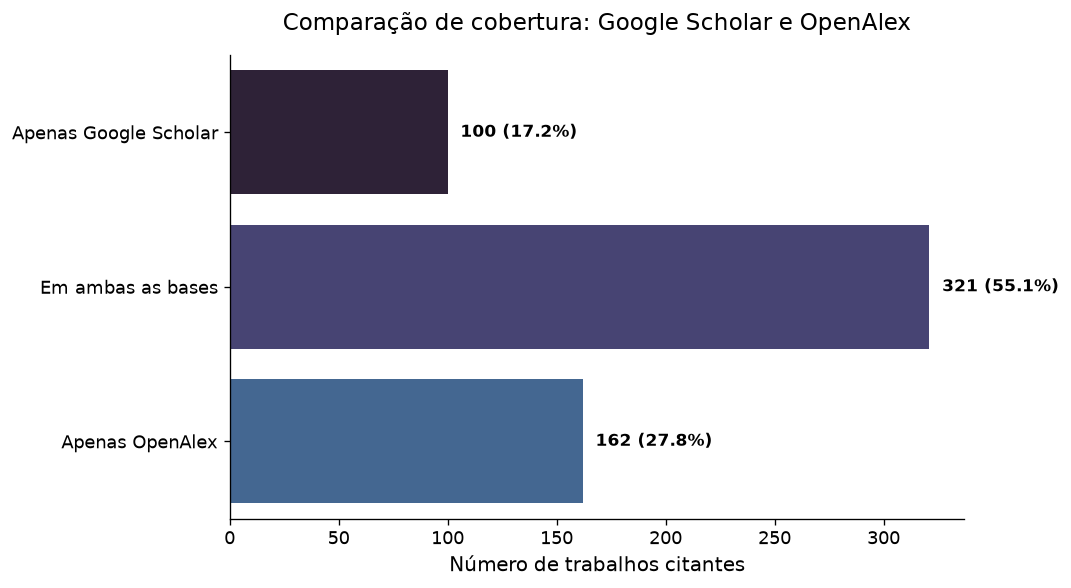

In [91]:
plt.figure(figsize=(9, 5))

base_colors = sns.color_palette("mako", 6)
colors = [base_colors[i % len(base_colors)] for i in range(len(df_sobreposicao["Categoria"]))]

ax = sns.barplot(data=df_sobreposicao, x="Total de trabalhos", y="Categoria", hue="Categoria", palette=colors, legend=False)
ax.set_title("Comparação de cobertura: Google Scholar e OpenAlex", fontsize=14, pad=15)
ax.set_xlabel("Número de trabalhos citantes", fontsize=12)

ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for p, total, pct in zip(ax.patches, df_sobreposicao["Total de trabalhos"], df_sobreposicao["Percentual (%)"]):
    if total > 0:
        ax.annotate(
            f"{int(total):,} ({pct:.1f}%)",
            (
                p.get_width() + total_unico * 0.01,
                p.get_y() + p.get_height() / 2
            ),
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

sns.despine()
plt.tight_layout()
plt.show()